# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [20]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [21]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [22]:
import sklearn
print(sklearn.__version__)

1.8.0


In [23]:
# ^^ installed scikit-learn 

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


In [5]:
# ^^ read about the classifers 

### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [24]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [25]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]

We can train the classifier as follow:

In [28]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

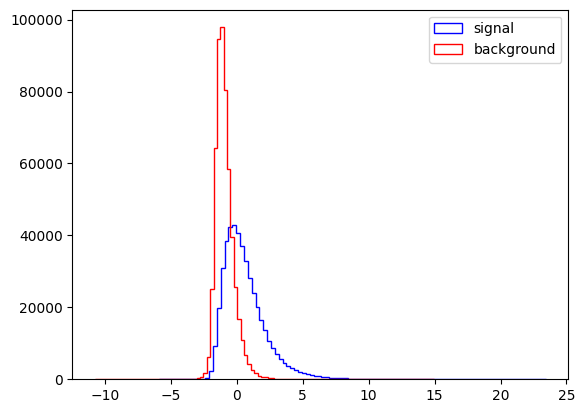

In [29]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

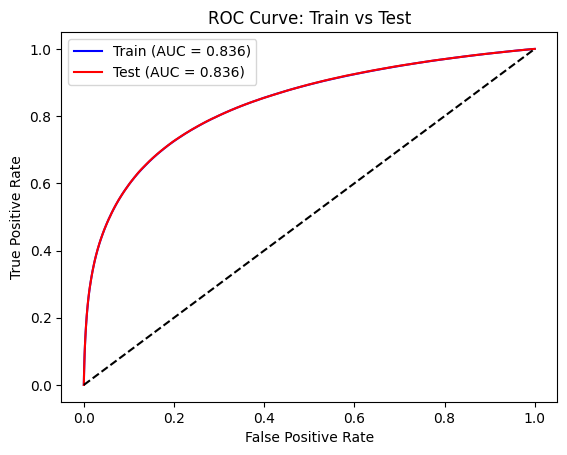

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

train_scores = Fisher.decision_function(X_Train)
test_scores  = Fisher.decision_function(X_Test)

fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)
fpr_test,  tpr_test,  _ = roc_curve(y_Test,  test_scores)

auc_train = auc(fpr_train, tpr_train)
auc_test  = auc(fpr_test,  tpr_test)

plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.3f})", color="blue")
plt.plot(fpr_test,  tpr_test,  label=f"Test (AUC = {auc_test:.3f})",  color="red")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs Test")
plt.legend()
plt.show()

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [36]:
df["pt_ratio"] = df["l_1_pT"] / (df["l_2_pT"] + 1e-6)
df["pt_sum"]   = df["l_1_pT"] + df["l_2_pT"]
df["eta_diff"] = df["l_1_eta"] - df["l_2_eta"]
df["phi_diff"] = df["l_1_phi"] - df["l_2_phi"]
df["met_lep"]  = df["MET"] / (df["l_1_pT"] + df["l_2_pT"] + 1e-6)

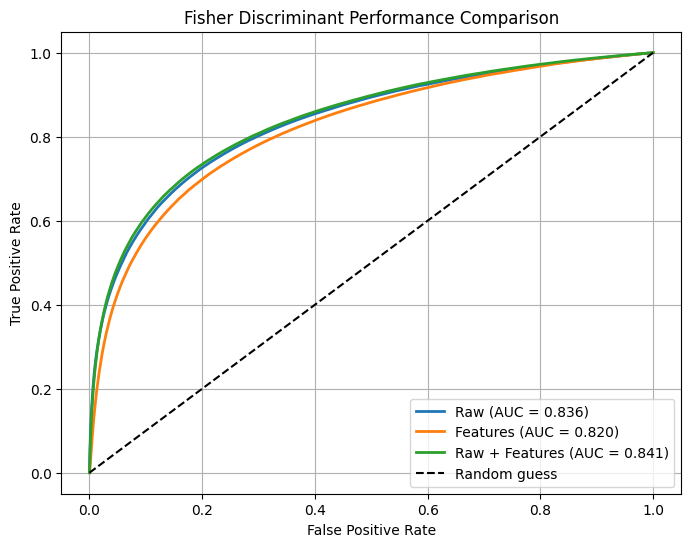

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc

RawVars = VarNames[1:]

# feature engineering
df["pt_ratio"] = df["l_1_pT"] / (df["l_2_pT"] + 1e-6)
df["pt_sum"]   = df["l_1_pT"] + df["l_2_pT"]
df["eta_diff"] = df["l_1_eta"] - df["l_2_eta"]
df["phi_diff"] = df["l_1_phi"] - df["l_2_phi"]
df["met_lep"]  = df["MET"] / (df["l_1_pT"] + df["l_2_pT"] + 1e-6)

FeatureVars = ["pt_ratio", "pt_sum", "eta_diff", "phi_diff", "met_lep"]
AllVars = RawVars + FeatureVars

# train test split
Train_Sample = df[:N_Train]
Test_Sample  = df[N_Train:]

y_Train = Train_Sample["signal"]
y_Test  = Test_Sample["signal"]

X_train_raw  = Train_Sample[RawVars]
X_train_feat = Train_Sample[FeatureVars]
X_train_all  = Train_Sample[AllVars]

X_test_raw  = Test_Sample[RawVars]
X_test_feat = Test_Sample[FeatureVars]
X_test_all  = Test_Sample[AllVars]

lda_raw  = LinearDiscriminantAnalysis()
lda_feat = LinearDiscriminantAnalysis()
lda_all  = LinearDiscriminantAnalysis()

lda_raw.fit(X_train_raw, y_Train)
lda_feat.fit(X_train_feat, y_Train)
lda_all.fit(X_train_all, y_Train)

scores_raw  = lda_raw.decision_function(X_test_raw)
scores_feat = lda_feat.decision_function(X_test_feat)
scores_all  = lda_all.decision_function(X_test_all)

def compute_roc(y_true, scores):
    fpr, tpr, _ = roc_curve(y_true, scores)
    return fpr, tpr, auc(fpr, tpr)

fpr_r, tpr_r, auc_r = compute_roc(y_Test, scores_raw)
fpr_f, tpr_f, auc_f = compute_roc(y_Test, scores_feat)
fpr_a, tpr_a, auc_a = compute_roc(y_Test, scores_all)

plt.figure(figsize=(8,6))

plt.plot(fpr_r, tpr_r, label=f"Raw (AUC = {auc_r:.3f})", linewidth=2)
plt.plot(fpr_f, tpr_f, label=f"Features (AUC = {auc_f:.3f})", linewidth=2)
plt.plot(fpr_a, tpr_a, label=f"Raw + Features (AUC = {auc_a:.3f})", linewidth=2)

plt.plot([0,1], [0,1], 'k--', label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher Discriminant Performance Comparison")
plt.legend()
plt.grid()
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [41]:
# part a

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

lda = LinearDiscriminantAnalysis()  # Fisher / linear model
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
gb  = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# classifiers = LDA, Random Forest, Gradient Boosting

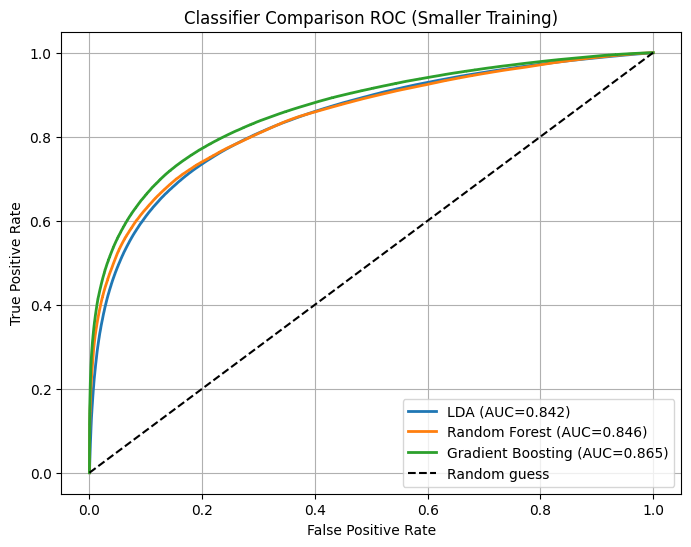

AUCs (fast training): LDA=0.842, RF=0.846, GB=0.865


In [43]:
# part b

import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc

# using smaller subset
N_Train_small = 200_000  # 200k instead of 4M
Train_Sample_small = df[:N_Train_small]

X_train_small = Train_Sample_small[AllVars]
y_train_small = Train_Sample_small["signal"]

X_test_all  = df[N_Train:][AllVars]
y_test_all  = df[N_Train:]["signal"]

lda = LinearDiscriminantAnalysis()
rf  = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
gb  = GradientBoostingClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42)

def compare_classifier(clf, X_train, y_train, X_test, y_test, label="Classifier"):
    clf.fit(X_train, y_train)
    
    try:
        scores = clf.decision_function(X_test)
    except AttributeError:
        scores = clf.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})", linewidth=2)
    
    return roc_auc

plt.figure(figsize=(8,6))

auc_lda = compare_classifier(lda, X_train_small, y_train_small, X_test_all, y_test_all, label="LDA")
auc_rf  = compare_classifier(rf,  X_train_small, y_train_small, X_test_all, y_test_all, label="Random Forest")
auc_gb  = compare_classifier(gb,  X_train_small, y_train_small, X_test_all, y_test_all, label="Gradient Boosting")

plt.plot([0,1],[0,1],'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier Comparison ROC (Smaller Training)")
plt.legend()
plt.grid()
plt.show()

print(f"AUCs (fast training): LDA={auc_lda:.3f}, RF={auc_rf:.3f}, GB={auc_gb:.3f}")

In [45]:
# part c

import numpy as np

def maximal_sigma_S(clf, X_test, y_test, bins=100):
    try:
        scores = clf.decision_function(X_test)
    except AttributeError:
        scores = clf.predict_proba(X_test)[:,1]
    
    thresholds = np.linspace(min(scores), max(scores), bins)
    max_sigma = 0
    best_thr = 0
    
    for thr in thresholds:
        N_S = np.sum(scores[y_test==1] > thr)
        N_B = np.sum(scores[y_test==0] > thr)
        if N_S + N_B > 0:
            sigma = N_S / np.sqrt(N_S + N_B)
            if sigma > max_sigma:
                max_sigma = sigma
                best_thr = thr
                
    return max_sigma, best_thr

clf_best = gb 
clf_best.fit(X_train_small, y_train_small)

sigma_S_max, best_threshold = maximal_sigma_S(clf_best, X_test_all, y_test_all)

print(f"Maximal significance σ_S = {sigma_S_max:.3f}")
print(f"Threshold giving maximal σ_S: {best_threshold:.3f}")

Maximal significance σ_S = 520.694
Threshold giving maximal σ_S: -0.479


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [46]:
# read about part a

                 Metric       Value
0                   AUC    0.865220
1             Precision    0.821164
2                Recall    0.703308
3              F1 Score    0.757680
4              Accuracy    0.793859
5  Max Significance σ_S  520.694356


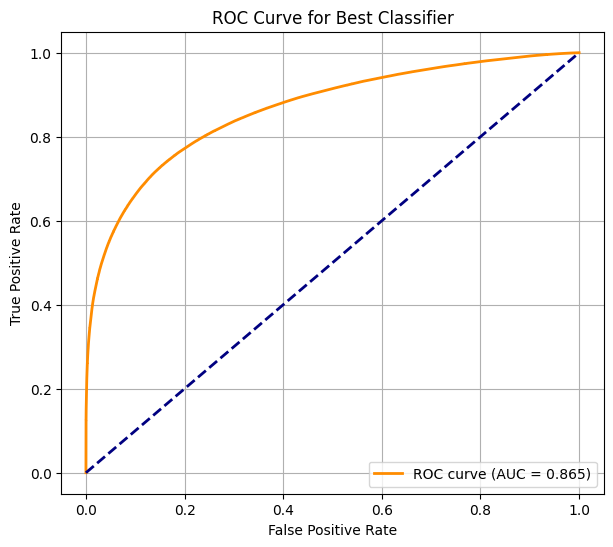

In [47]:
# part b

from sklearn.metrics import (
    roc_curve, auc, precision_score, recall_score,
    f1_score, accuracy_score
)
import pandas as pd
import numpy as np

clf_best.fit(X_train_small, y_train_small)  # train on smaller subset
y_scores = clf_best.predict_proba(X_test_all)[:,1]
y_pred   = clf_best.predict(X_test_all)

fpr, tpr, thresholds = roc_curve(y_test_all, y_scores)
roc_auc = auc(fpr, tpr)

precision = precision_score(y_test_all, y_pred)
recall    = recall_score(y_test_all, y_pred)
f1        = f1_score(y_test_all, y_pred)
accuracy  = accuracy_score(y_test_all, y_pred)

def maximal_sigma_S(clf, X_test, y_test, bins=100):
    try:
        scores = clf.decision_function(X_test)
    except AttributeError:
        scores = clf.predict_proba(X_test)[:,1]
    
    thresholds = np.linspace(min(scores), max(scores), bins)
    max_sigma = 0
    best_thr = 0
    
    for thr in thresholds:
        N_S = np.sum(scores[y_test==1] > thr)
        N_B = np.sum(scores[y_test==0] > thr)
        if N_S + N_B > 0:
            sigma = N_S / np.sqrt(N_S + N_B)
            if sigma > max_sigma:
                max_sigma = sigma
                best_thr = thr
    return max_sigma, best_thr

sigma_S_max, best_threshold = maximal_sigma_S(clf_best, X_test_all, y_test_all)

metrics_table = pd.DataFrame({
    "Metric": ["AUC", "Precision", "Recall", "F1 Score", "Accuracy", "Max Significance σ_S"],
    "Value": [roc_auc, precision, recall, f1, accuracy, sigma_S_max]
})

print(metrics_table)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Best Classifier')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [48]:
# ChatGPT helped me a lot. 